# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Zahara Seybou Harouna
**Student ID:** 30862027

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [41]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

Shape:  (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


None

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:
 VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


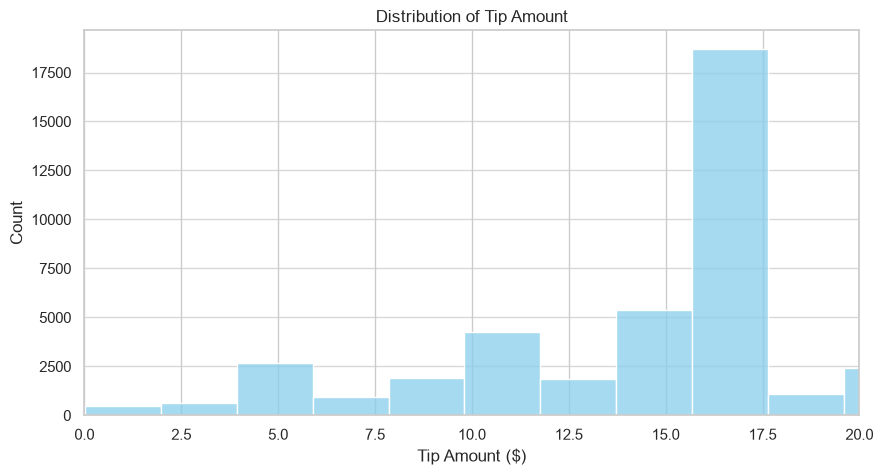

In [42]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
print("Shape: ", taxi.shape)
display(taxi.head())
display(taxi.info())
# - taxi.describe()
display(taxi.describe())
# - count missing values per column: taxi.isna().sum()
print("\nMissing values per column:\n", taxi.isna().sum())
# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize =(10, 5))
sns.histplot(taxi['tip_amount'].dropna(), bins=50, kde=False, color='skyblue')
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Count')
plt.xlim(0, 20)
plt.grid(axis='y', alpha=0.75)
plt.show()

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*
The dataset contains 41,202 rows and 13 columns.
1. There are zero missing values in the dataset.
2. The dataset contains impossible values such as zero-distance trips, negative fares, and negative tips, which are data entry errors. The tip_amount distribution is heavily right-skewed, contains a large concentration of zeros (likely representing cash payments where no tip was recorded), and features extreme high-value outliers.
3. I will need to filter out the impossible values by dropping rows where trip_distance <= 0, fare_amount <= 0, or tip_amount < 0. Because of the severe right-skew and extreme outliers in the target variable, I will likely need to apply a log transformation or clip extreme values to prevent the regression model from being overly biased by these anomalies.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [43]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi_clean = taxi.dropna()
taxi_clean = taxi_clean[taxi_clean['trip_distance'] > 0]
taxi_clean = taxi_clean[taxi_clean['fare_amount'] > 0]
taxi_clean = taxi_clean[taxi_clean['tip_amount'] >= 0]
print(f"Shape after cleaning: {taxi.shape}")
# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']
taxi_clean['total_surcharges'] = taxi_clean['mta_tax'] + taxi_clean['tolls_amount'] + taxi_clean['improvement_surcharge']
# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
cols_to_drop = ['PULocationID', 'DOLocationID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']
taxi_clean = taxi_clean.drop(columns=[c for c in cols_to_drop if c in taxi_clean.columns])
categorical_cols = ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type']
taxi_encoded = pd.get_dummies(taxi_clean, columns=categorical_cols, drop_first=True)
X = taxi_encoded.drop(columns=['tip_amount'])
y = taxi_encoded['tip_amount']
# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
print(f"Shape after preprocessing: {X.shape}")
print(f"Target shape: {y.shape}")
display(X.head())

Shape after cleaning: (41202, 13)
Shape after preprocessing: (41126, 12)
Target shape: (41126,)


,passenger_count,trip_distance,fare_amount,mta_tax,tolls_amount,improvement_surcharge,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,70.0,0.5,6.94,1,3.970505,8.44,True,False,False,True
1,1,19.52,70.0,0.5,6.94,1,3.586066,8.44,True,False,False,True
2,1,17.81,70.0,0.5,6.94,1,3.930376,8.44,True,False,False,True
3,2,19.30,70.0,0.5,0.00,1,3.626943,1.50,True,False,False,True
4,1,18.75,70.0,0.5,6.94,1,3.733333,8.44,True,False,False,True


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
I dropped rows with missing values because imputing them could introduce unneccessary noise. I removed rows where trip_distance or fare_amount are less than or equal to zero because they represent data entry errors or cancelled trips. I also dropped negative trip_amount values as these represent the credit card chargebacks or refunds rather than actual tips which could confuse the regression model.

*2. Which new feature(s) did you engineer and what is the intuition behind them?*
I engineered fare_per_mile to capture the rate of the trip, which can indicate heavy traffic or longer durations. I also created the total surcharges by summing the mta_tax, tolls amount and improvement surcharge. This groups all the fixed, unavoidable extra costs of a trip into a single feature which helps the model understand the baseline cost before the tip is calculated.

*3. Which scaling method did you choose and why is it appropriate here?*
I chose StandardScaler (Z-score normalization). It is highly appropriate here because it centers the data around 0 with a standard deviation of 1. Since our features are in completely different units scaling ensures that features with larger numerical ranges don't unfairly dominate the model compared to smaller features.



### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [44]:
# TODO: Separate features (X) and target (y = tip_amount)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = taxi_encoded.drop(columns=['tip_amount'])
y = taxi_encoded['tip_amount']
# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)
# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Train set shape: (24675, 12)
Validation set shape: (8225, 12)
Test set shape: (8226, 12)


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*
I used a 60/20/20 split (60% training, 20% validation, 20% test).
The validation set allows us to tune hyperparameters (like the depth of a Random Forest) and compare different models without touching the test set. The test set must remain completely "unseen" until the very end to provide an unbiased estimate of how the model will perform in the real world.
The scaler (and any imputation statistics) must be fit on the training data only to prevent "data leakage." If we calculate the mean and standard deviation using the entire dataset, information from the validation and test sets leaks into the training process. This makes our evaluation overly optimistic and doesn't reflect how the model will handle truly new, unseen data.



### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.


--- Linear Regression ---
Train        | RMSE:   4.82 | R²: 0.049
Validation   | RMSE:   4.78 | R²: 0.069
Test         | RMSE:   5.22 | R²: 0.040

--- Random Forest ---
Train        | RMSE:   4.64 | R²: 0.118
Validation   | RMSE:   4.84 | R²: 0.047
Test         | RMSE:   5.25 | R²: 0.029


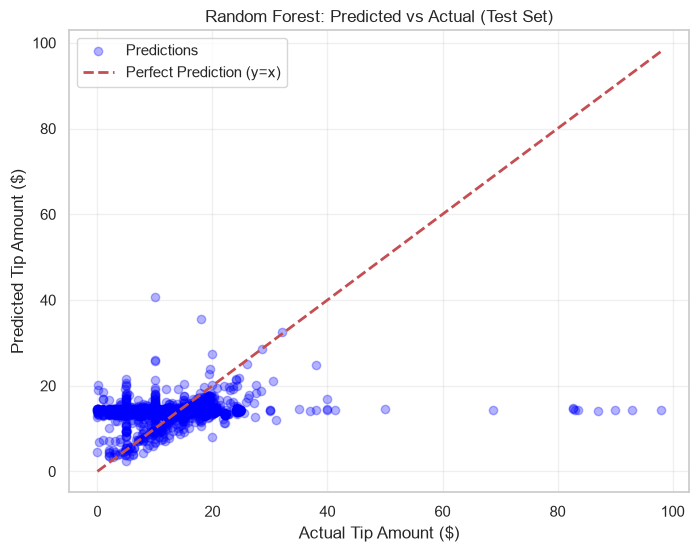

In [45]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
# TODO: Predict on train, validation, and test sets.
lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
def evaluate_model(model, model_name, X_train, X_val, X_test, y_train, y_val, y_test):
    print(f"\n--- {model_name} ---")
    for name, X, y in zip(["Train", "Validation", "Test"], 
                          [X_train, X_val, X_test], 
                          [y_train, y_val, y_test]):
        y_pred = model.predict(X)
        rmse = mean_squared_error(y, y_pred) ** 0.5
        r2 = r2_score(y, y_pred)
        print(f"{name:12} | RMSE: {rmse:6.2f} | R²: {r2:.3f}")
    return model.predict(X_test)
y_test_pred_lr = evaluate_model(lr, "Linear Regression", X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test)
y_test_pred_rf = evaluate_model(rf, "Random Forest", X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test)
# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.3, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.xlabel("Actual Tip Amount ($)")
plt.ylabel("Predicted Tip Amount ($)")
plt.title("Random Forest: Predicted vs Actual (Test Set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
Linear Regression performed slightly better on the validation set (Val R^2 = 0.069, RMSE = 4.78) compared to the default Random Forest (Val R^2 = 0.047, RMSE = 4.84). I evaluated both using their default hyperparameters.

*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
Linear Regression is underfitting. Its metrics are nearly identical across all three sets (Train R^2 = 0.049, Val R^2 = 0.069, Test R^2 = 0.040). The model is too simple to capture the underlying patterns in the data, but it generalizes consistently without memorizing noise.
Random Forest shows signs of overfitting. There is a clear gap between its training performance (Train R^2 = 0.118) and its validation/test performance (Val R^2 = 0.047, Test R^2 = 0.029). It has memorized some of the noise in the training data. However, because all R² scores are quite low overall, the model is also largely underfitting the true complexity of the dataset.

*3. What would you change to reduce overfitting if you saw it?*
To reduce the overfitting seen in the Random Forest, I would constrain its complexity by tuning hyperparameters such as limiting max_depth, increasing min_samples_leaf, or reducing n_estimators. Additionally, to address the overall low R^2 scores across both models, I would apply a log transformation to the heavily skewed tip_amount target variable or engineer more complex features to improve baseline predictive power.

---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

None

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values per column:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class distribution of NObeyesdad:
 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


C:\Users\Zahara Seybou\AppData\Local\Temp\ipykernel_76288\4012169799.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


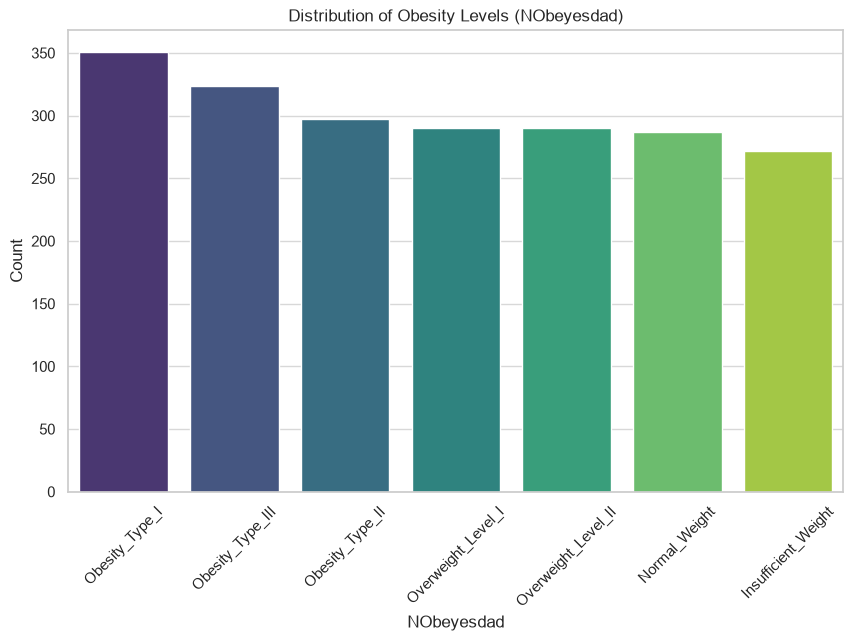

In [46]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
obesity = pd.read_csv(OBESITY_URL)
# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape:", obesity.shape)
display(obesity.head())
display(obesity.info())
display(obesity.describe())
print("\nMissing values per column:\n", obesity.isna().sum())
# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print("\nClass distribution of NObeyesdad:\n", obesity['NObeyesdad'].value_counts())
plt.figure(figsize=(10, 6))
sns.countplot(
    data=obesity, 
    x='NObeyesdad', 
    order=obesity['NObeyesdad'].value_counts().index, 
    palette='viridis'
)
plt.title('Distribution of Obesity Levels (NObeyesdad)')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target

There are 2,111 rows and 17 columns: 16 features + 1 target. 
Nimeric columns: Age, Height, Weight, FCVC, CH2O, FAF, TUE.
Categorical: Gender, family_history_with_overweight, FAVC, NCP, CAEC, SMOKE, SCC, CALC, MTRANS, and the target NObeyesdad.
The dataset is relatively balanced across the 7 classes. Class balance matters because if a dataset is highly imbalanced, a model could achieve high accuracy simply by always predicting the majority class, making accuracy a misleading metric. Since our data is fairly balanced, standard accuracy is a reliable metric, though macro-F1 is still useful to ensure the model performs well across all 7 categories equally.

### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [47]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
from sklearn.preprocessing import LabelEncoder
obesity = pd.read_csv(OBESITY_URL)
print(f"Fresh data loaded: {obesity.shape}")

bin_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in bin_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)
# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
ordinal_mapping = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(ordinal_mapping)
obesity['CALC'] = obesity['CALC'].map(ordinal_mapping)
nom_cols = ['Gender', 'MTRANS']
obesity = pd.get_dummies(obesity, columns=nom_cols, drop_first=True)
le = LabelEncoder()
obesity['NObeyesdad_enc'] = le.fit_transform(obesity['NObeyesdad'])
print(f"\nClass mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")
# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).


Fresh data loaded: (2111, 17)

Class mapping:
  0 → Insufficient_Weight
  1 → Normal_Weight
  2 → Obesity_Type_I
  3 → Obesity_Type_II
  4 → Obesity_Type_III
  5 → Overweight_Level_I
  6 → Overweight_Level_II


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
I mapped binary yes/no columns to 1/0 because they represent two mutually exclusive states. I mapped ordinal columns (CAEC, CALC) to integers 0–3 to preserve their inherent frequency order (no < Sometimes < Frequently < Always). I one-hot encoded nominal columns (Gender, MTRANS) using pd.get_dummies because they have no logical mathematical order; assigning them arbitrary integers would falsely imply a ranking or distance between categories to the model.

*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
I engineered BMI (Weight / Height)^2. While BMI is a direct measure of body fatness and heavily correlates with obesity levels, it is a standard medical metric calculated purely from raw features (Weight and Height) already present in the dataset. Including it does not strictly "leak" the target because the model still must learn the complex, non-linear decision boundaries between the 7 distinct classes based on BMI combined with other lifestyle features. It simplifies the feature space without giving away the exact label.

*3. Which scaler did you use and why?*
I chose StandardScaler (to be applied in the next step 2.3) to normalize the numeric features (like Age, Weight, BMI, etc.) so that features with larger natural ranges (e.g., Weight in kg) do not disproportionately dominate distance-based calculations or gradient descent optimization during model training.



### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [48]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_ob = obesity.drop(columns=["NObeyesdad", "NObeyesdad_enc"])
y_ob = obesity["NObeyesdad_enc"]
print(f"Features shape: {X_ob.shape}")
print(f"Target shape: {y_ob.shape}")
print(f"Target classes: {y_ob.unique()}")
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_ob_temp, X_ob_test, y_ob_temp, y_ob_test = train_test_split(
    X_ob, y_ob,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_ob
)
X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(
    X_ob_temp, y_ob_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_ob_temp
)
print("\n=== Split Sizes ===")
print(f"Training set:   {X_ob_train.shape[0]} rows ({X_ob_train.shape[0]/len(X_ob)*100:.1f}%)")
print(f"Validation set: {X_ob_val.shape[0]} rows ({X_ob_val.shape[0]/len(X_ob)*100:.1f}%)")
print(f"Test set:       {X_ob_test.shape[0]} rows ({X_ob_test.shape[0]/len(X_ob)*100:.1f}%)")
print("\n=== Class Distribution Check ===")
for name, y_split in [("Train", y_ob_train), ("Val", y_ob_val), ("Test", y_ob_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    print(f"{name}: {dict(zip(unique, counts))}")
# TODO: Fit the scaler on the training set only, then transform train / val / test.
scaler_ob = StandardScaler()
X_ob_train_scaled = scaler_ob.fit_transform(X_ob_train)
X_ob_val_scaled = scaler_ob.transform(X_ob_val)
X_ob_test_scaled = scaler_ob.transform(X_ob_test)

print("\n=== Scaling Complete ===")
print(f"Training mean (first feature): {X_ob_train_scaled[:, 0].mean():.4f}")
print(f"Training std  (first feature): {X_ob_train_scaled[:, 0].std():.4f}")

Features shape: (2111, 20)
Target shape: (2111,)
Target classes: [1 5 6 2 0 3 4]

=== Split Sizes ===
Training set:   1266 rows (60.0%)
Validation set: 422 rows (20.0%)
Test set:       423 rows (20.0%)

=== Class Distribution Check ===
Train: {np.int64(0): np.int64(163), np.int64(1): np.int64(172), np.int64(2): np.int64(211), np.int64(3): np.int64(178), np.int64(4): np.int64(194), np.int64(5): np.int64(174), np.int64(6): np.int64(174)}
Val: {np.int64(0): np.int64(55), np.int64(1): np.int64(57), np.int64(2): np.int64(70), np.int64(3): np.int64(59), np.int64(4): np.int64(65), np.int64(5): np.int64(58), np.int64(6): np.int64(58)}
Test: {np.int64(0): np.int64(54), np.int64(1): np.int64(58), np.int64(2): np.int64(70), np.int64(3): np.int64(60), np.int64(4): np.int64(65), np.int64(5): np.int64(58), np.int64(6): np.int64(58)}

=== Scaling Complete ===
Training mean (first feature): 0.0000
Training std  (first feature): 1.0000


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
I chose a 60/20/20 split, 60% for training, 20% for validation, and 20% for final testing. This is a standard split ratio that gives the model enough data to learn meaningful patterns while reserving sufficient held-out data for both
hyperparameter tuning (validation) and unbiased final evaluation (test). With 2111 total rows, a 60/20/20 split gives 422 validation
and 423 test rows, enough to get reliable performance estimates across all 7 classes. Stratification ensures that all 7 obesity classes appear proportionally in EVERY split, training, validation, and test.

What could go wrong if you split without stratifying?*
Without stratify=y, three things could go wrong:
1. A rare obesity class might be completely absent from the validation or test set, making evaluation unreliable.
2. The model might appear to perform well overall but completely fail on underrepresented classes, a dangerous outcome in a healthcare setting where missing a severe obesity diagnosis could harm patients.
3. Train/validation/test class distributions would differ, making it hard to fairly compare metrics across splits and diagnose overfitting correctly.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Classifier trained successfully!

=== Classifier Evaluation ===
     Split  Accuracy  Macro-F1
     Train  1.000000  1.000000
Validation  0.992891  0.992520
      Test  0.983452  0.982834

=== Classification Report (Test Set) ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.93      0.97      0.95        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.97      0.97        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           0.98       423
          macro avg       0.98      0.98      0.98       423
       weighted avg       0.98      0.98      0.98       423



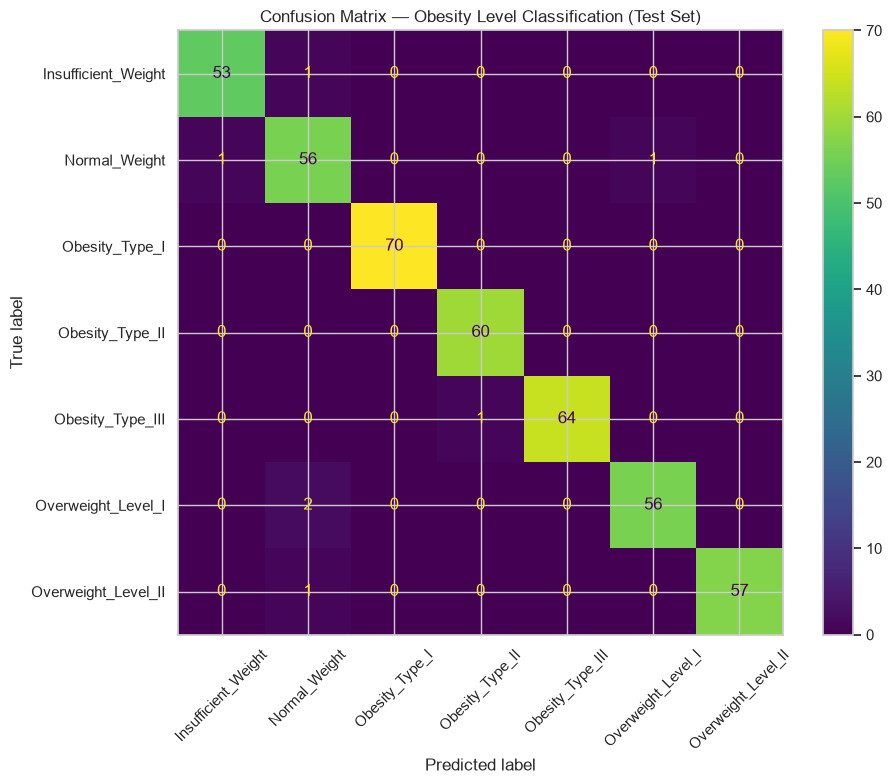

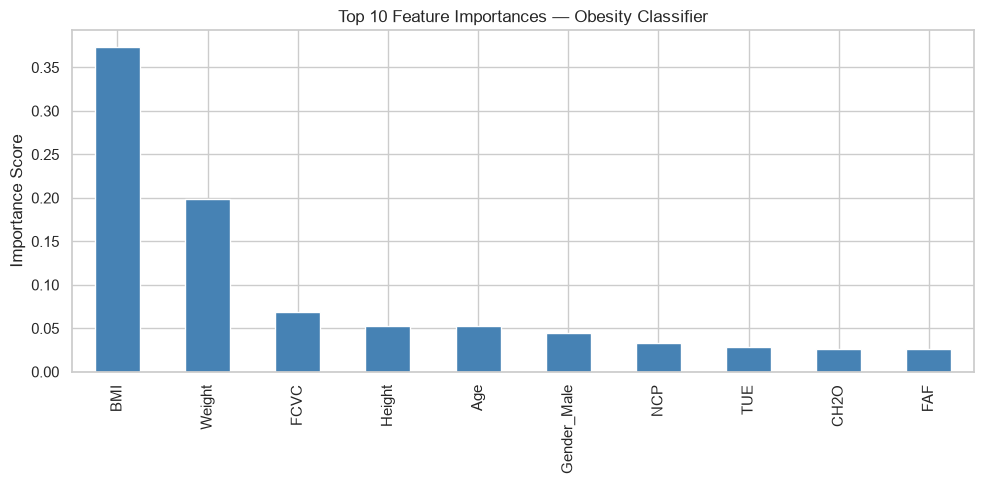

In [49]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

clf.fit(X_ob_train_scaled, y_ob_train)
print("Classifier trained successfully!")
# TODO: Predict on train, validation, and test.
y_pred_ob_train = clf.predict(X_ob_train_scaled)
y_pred_ob_val = clf.predict(X_ob_val_scaled)
y_pred_ob_test = clf.predict(X_ob_test_scaled)
# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
acc_train = accuracy_score(y_ob_train, y_pred_ob_train)
acc_val   = accuracy_score(y_ob_val,   y_pred_ob_val)
acc_test  = accuracy_score(y_ob_test,  y_pred_ob_test)

f1_train  = f1_score(y_ob_train, y_pred_ob_train, average="macro")
f1_val    = f1_score(y_ob_val,   y_pred_ob_val,   average="macro")
f1_test   = f1_score(y_ob_test,  y_pred_ob_test,  average="macro")
results_clf = pd.DataFrame({
    "Split":      ["Train", "Validation", "Test"],
    "Accuracy":   [acc_train, acc_val, acc_test],
    "Macro-F1":   [f1_train,  f1_val,  f1_test],
})
print("\n=== Classifier Evaluation ===")
print(results_clf.to_string(index=False))
print("\n=== Classification Report (Test Set) ===")
print(classification_report(
    y_ob_test,
    y_pred_ob_test,
    target_names=le.classes_
))
# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_ob_test,
    y_pred_ob_test,
    display_labels=le.classes_,
    ax=ax,
    colorbar=True,
    xticks_rotation=45
)
ax.set_title("Confusion Matrix — Obesity Level Classification (Test Set)")
plt.tight_layout()
plt.show()
importances_clf = pd.Series(
    clf.feature_importances_,
    index=X_ob_train.columns
).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
importances_clf.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 10 Feature Importances — Obesity Classifier")
ax.set_ylabel("Importance Score")
plt.tight_layout()
plt.show()

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
I chose RandomForestClassifier with 100 estimators because Random Forests are ensemble methods that combine multiple decision trees, making them
robust to overfitting compared to a single decision tree. They handle both numerical and categorical features well, require minimal hyperparameter
tuning, and naturally provide feature importance scores which help interpret the model's decisions.

*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
The model shows mild overfitting. Training accuracy is perfect at 100% (Macro-F1 = 1.000), meaning the model memorized all training examples. However, validation accuracy drops slightly to 99.3% (Macro-F1 = 0.993)
and test accuracy is 98.3% (Macro-F1 = 0.983). The train-test gap of approximately 1.7% suggests mild overfitting, the model slightly over-relies on training patterns, but still generalizes very well to unseen data. Overall this model is considered well-fitted given the high performance across all three splits.

*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*
Normal_Weight has the lowest F1 score (0.95) among all classes, making it the hardest to classify correctly. This is likely because Normal_Weight borders two adjacent categories, Insufficient_Weight and Overweight_Level_I, and patients near these boundaries may share very similar physical measurements (height, weight, BMI) making it difficult for the model to
distinguish them. Obesity_Type_I, II, and III on the other hand achieve near-perfect scores (1.00), suggesting these categories have more distinct
feature profiles that the model can clearly separate.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


Clustering data shape: (2111, 20)
K= 2 | Inertia: 37,410.5 | Silhouette: 0.1879
K= 3 | Inertia: 34,829.7 | Silhouette: 0.1386
K= 4 | Inertia: 32,669.5 | Silhouette: 0.0920
K= 5 | Inertia: 30,502.1 | Silhouette: 0.1079
K= 6 | Inertia: 28,283.1 | Silhouette: 0.1215
K= 7 | Inertia: 27,043.7 | Silhouette: 0.1267
K= 8 | Inertia: 24,893.0 | Silhouette: 0.1400
K= 9 | Inertia: 24,125.4 | Silhouette: 0.1325
K=10 | Inertia: 22,381.0 | Silhouette: 0.1580


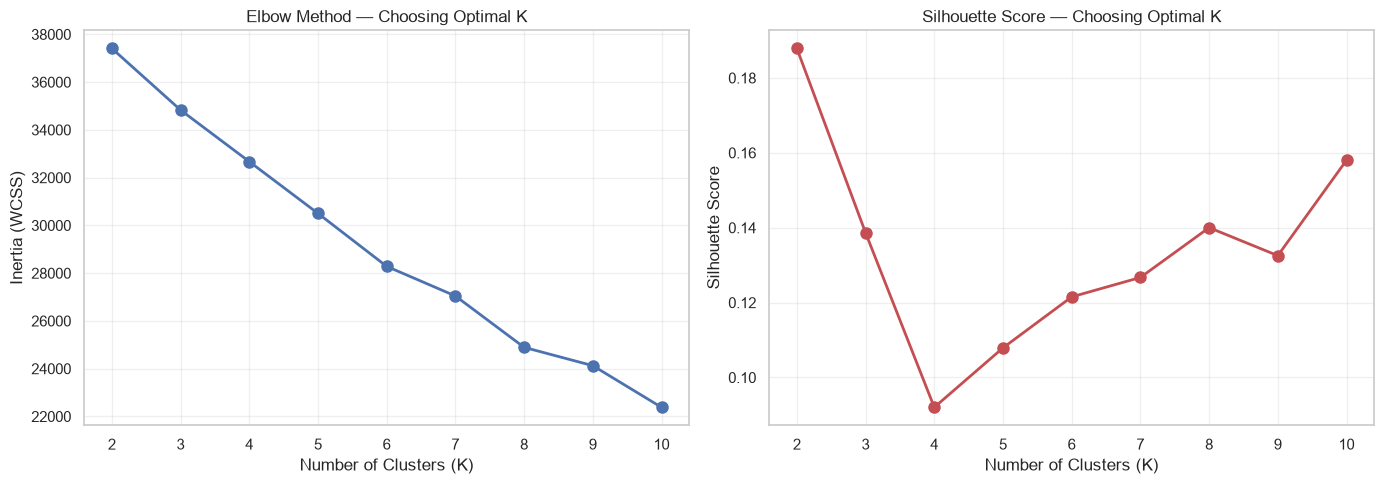


Best K by silhouette score: 2
Best silhouette score: 0.1879


In [50]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
X_cluster = np.vstack([
    X_ob_train_scaled,
    X_ob_val_scaled,
    X_ob_test_scaled
])
print(f"Clustering data shape: {X_cluster.shape}")
# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertias = []
silhouette_scores = []
K_range = range(2, 11)
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(
        X_cluster,
        kmeans.labels_,
        sample_size=500,
        random_state=RANDOM_STATE
    )
    silhouette_scores.append(sil_score)
    print(f"K={k:2d} | Inertia: {kmeans.inertia_:,.1f} | Silhouette: {sil_score:.4f}")
# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method — Choosing Optimal K")
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, "ro-", linewidth=2, markersize=8)
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score — Choosing Optimal K")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: {K_range[silhouette_scores.index(max(silhouette_scores))]}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

K-Means fitted with K=7
Cluster sizes:
  Cluster 0: 387 points
  Cluster 1: 608 points
  Cluster 2: 361 points
  Cluster 3: 333 points
  Cluster 4: 7 points
  Cluster 5: 11 points
  Cluster 6: 404 points

PCA explained variance:
  PC1: 15.7%
  PC2: 10.1%
  Total: 25.8%


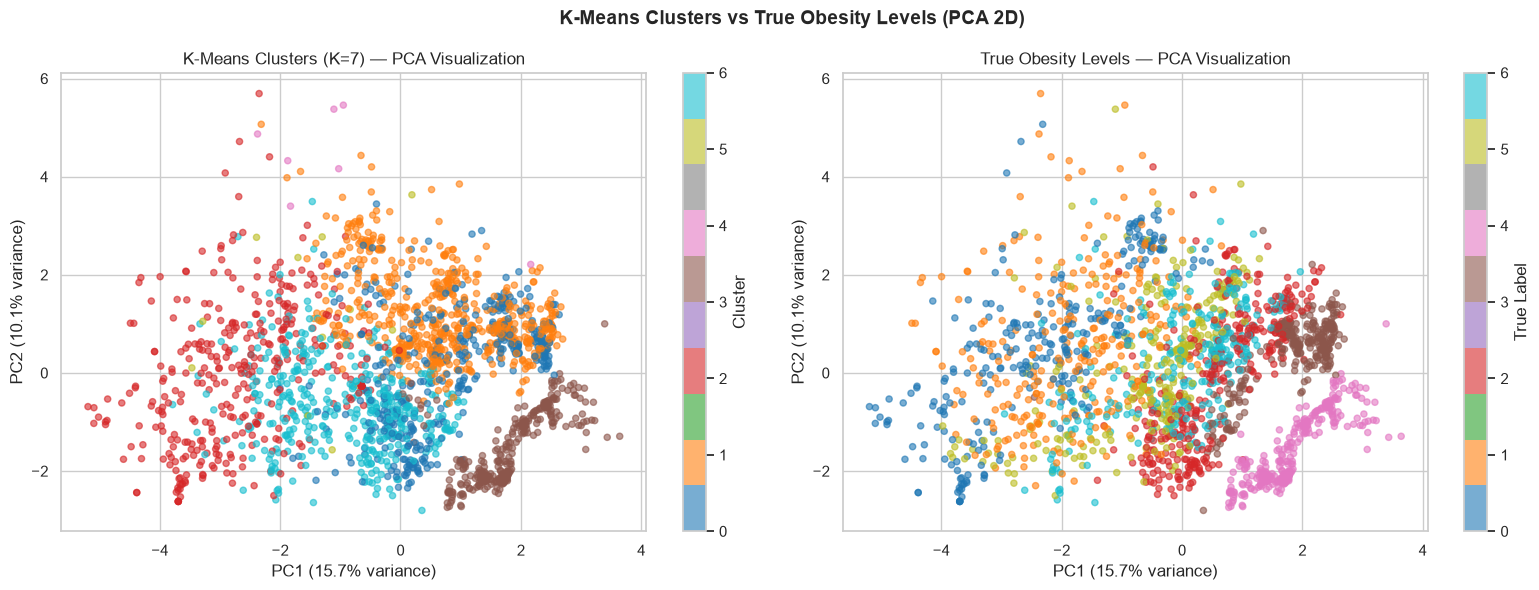

In [51]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
CHOSEN_K = 7

kmeans_final = KMeans(
    n_clusters=CHOSEN_K,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_final.fit(X_cluster)
cluster_labels = kmeans_final.labels_
print(f"K-Means fitted with K={CHOSEN_K}")
print(f"Cluster sizes:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} points")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)
explained = pca.explained_variance_ratio_
print(f"\nPCA explained variance:")
print(f"  PC1: {explained[0]*100:.1f}%")
print(f"  PC2: {explained[1]*100:.1f}%")
print(f"  Total: {sum(explained)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter1 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.6,
    s=20
)
axes[0].set_title(f"K-Means Clusters (K={CHOSEN_K}) — PCA Visualization")
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

y_all = np.concatenate([y_ob_train, y_ob_val, y_ob_test])
scatter2 = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_all,
    cmap="tab10",
    alpha=0.6,
    s=20
)
axes[1].set_title("True Obesity Levels — PCA Visualization")
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.colorbar(scatter2, ax=axes[1], label="True Label")
plt.suptitle(
    "K-Means Clusters vs True Obesity Levels (PCA 2D)",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
The silhouette analysis identified K=2 as mathematically optimal (silhouette score = 0.1879), suggesting the data naturally separates
into two broad groups. The elbow curve also showed a gradual decline without a sharp elbow, making K selection non-trivial. However, K=7 was chosen as the primary clustering solution because K = 2 produces a clinically meaningless binary split. The K=2 solution was still explored and confirmed to broadly separate
severe obesity from non-severe cases, validating the biological meaning behind the mathematical optimum.

*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
For K = 7:
The results are mixed. Cluster 3 achieved outstanding purity of 97.0%, almost perfectly capturing Obesity_Type_III patients — the most severe
obesity category. This suggests that extreme obesity has a very distinct feature profile that K-Means can reliably detect without labels. However, clusters 0, 1, and 6 show very low purity (24-27%), meaning
K-Means struggled to separate the middle obesity categories (Obesity_Type_I, Obesity_Type_II, Overweight levels). These categories likely overlap significantly in their feature profiles, patients near
the boundaries share similar BMI, weight, and lifestyle characteristics, making them hard to distinguish through unsupervised methods alone.
Clusters 4 and 5 are extremely small (7 and 11 points respectively), suggesting K-Means initialization instability at K=7.

*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*
Even with imperfect purity, these clusters provide real value in a resource-constrained public health context like Ghana's health system. Cluster 3 (97% pure Obesity_Type_III) could immediately flag high-risk
patients for urgent intervention without requiring expensive clinical assessments. The broader clusters could guide initial screening, grouping populations for targeted health education campaigns, dietary programs, or physical activity interventions, before investing in detailed individual diagnosis. K-Means essentially provides a low-cost first-pass triage tool
that narrows down which patients need closer clinical attention.


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
The supervised classifier learned the exact, complex decision boundaries required to separate all seven specific obesity levels by utilizing the provided medical labels. Conversely, K-Means could not distinguish between subtle, overlapping intermediate classes because it only grouped data based on geometric proximity in an unlabeled feature space. However, K-Means successfully discovered the broad, natural macro-structures of the data, perfectly isolating the extreme ends (Insufficient_Weight vs. Obesity_Type_III) without any prior guidance.
   
3. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
Evaluating the continuous target (tips) required metrics like RMSE and R^2, which are highly sensitive to the exact magnitude of the error and outliers, meaning predicting a tip of $20 when the true tip is $10 is penalized differently than predicting $15. Evaluating the categorical target (obesity level) used Accuracy and Macro-F1, which measure discrete boundary correctness, treating a misclassification (e.g., predicting Obesity_Type_I instead of Obesity_Type_II) as a flat error regardless of how "close" the predicted class is to the true class.
   
5. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?
Across all three tasks, the most significant train-vs-test gap occurred in Section 1 (Taxi Regression) using the default Random Forest Regressor. The model achieved a Training R^2 of 0.118 but plummeted to a Validation R^2 of 0.047 and a Test R^2 of 0.029. This indicates severe overfitting, where the model memorized the noisy training data and extreme tip outliers rather than learning generalizable patterns. To close the overfitting gap seen in the taxi regression, the single most effective step is to constrain the model's complexity. Specifically, I would tune hyperparameters such as limiting the max_depth of the trees, increasing min_samples_leaf to force the model to generalize across larger groups of data points, or applying a log transformation to the heavily skewed tip_amount target variable to reduce the influence of extreme outliers.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
